In [135]:
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
import pylab as pl
import numpy as np

import warnings                              # Disable some warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)

In [136]:
pd.set_option('display.max_rows', None)      # show every row
pd.set_option('display.max_columns', None)   # (optional) show every column

In [374]:
file_name = "df_first_model.csv"
df = pd.read_csv(file_name)
df.dropna(inplace=True)
df['DDI'] = df['DDI'].astype(int)
df.head() 

,Unnamed: 0,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,player_id,shot_bodyPart_head_or_other,assist_type_long_pass,direct_free_kick,assist_type_through_pass,shot_distance,shot_angle,shot_xg,shot_isGoal,closest_frame,previous_frames,next_frames,match_info,R,goal_angle,DDI
0,0,2525775904,5590087,1H,14,5,00:14:05.838,846.838703,74,56,6713,472359,0,0,0,0,38.013156,22.249024,0.001169,0,"{'data': {'61258': [{'x': 81.4, 'y': 26.97, 'v...","[{'frame': {'data': {'61258': [{'x': 80.72, 'y...","[{'frame': {'data': {'61258': [{'x': 81.36, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,24.624803,16.587813,0
1,1,2525775981,5590087,1H,16,20,00:16:20.042,981.042219,90,53,6713,546236,0,0,0,1,24.207437,28.131342,0.369600,0,"{'data': {'61258': [{'x': 78.15, 'y': 34.96, '...","[{'frame': {'data': {'61258': [{'x': 77.51, 'y...","[{'frame': {'data': {'61258': [{'x': 78.26, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,12.127209,14.517517,0
2,2,2525775934,5590087,1H,17,22,00:17:22.682,1043.682911,88,50,8738,66175,0,0,0,0,23.345235,33.404163,0.019250,0,"{'data': {'61258': [{'x': 4.98, 'y': 28.52, 'v...","[{'frame': {'data': {'61258': [{'x': 3.66, 'y'...","[{'frame': {'data': {'61258': [{'x': 5.32, 'y'...",{'match_data': {'season_data': {'name': 'UCF 2...,13.676728,10.447233,0
3,3,2525776003,5590087,1H,23,31,00:23:31.670,1412.670761,89,50,8738,526355,1,0,0,0,22.627417,33.751379,0.152000,0,"{'data': {'61258': [{'x': 13.4, 'y': 27.82, 'v...","[{'frame': {'data': {'61258': [{'x': 13.06, 'y...","[{'frame': {'data': {'61258': [{'x': 13.47, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,12.396290,5.462242,1
4,4,2525776121,5590087,1H,25,25,00:25:25.953,1526.953456,87,50,6713,54783,1,0,0,0,24.083189,32.995607,0.031020,0,"{'data': {'61258': [{'x': 87.46, 'y': 31.86, '...","[{'frame': {'data': {'61258': [{'x': 87.12, 'y...","[{'frame': {'data': {'61258': [{'x': 87.48, 'y...",{'match_data': {'season_data': {'name': 'UCF 2...,6.845144,33.318625,0


## 1. Without tracking data

In [375]:
df_without_tracking= df[["shot_distance","shot_angle","assist_type_through_pass","assist_type_long_pass","shot_bodyPart_head_or_other","direct_free_kick","shot_isGoal"]]
df_without_tracking.head()

,shot_distance,shot_angle,assist_type_through_pass,assist_type_long_pass,shot_bodyPart_head_or_other,direct_free_kick,shot_isGoal
0,38.013156,22.249024,0,0,0,0,0
1,24.207437,28.131342,1,0,0,0,0
2,23.345235,33.404163,0,0,0,0,0
3,22.627417,33.751379,0,0,1,0,0
4,24.083189,32.995607,0,0,1,0,0


In [376]:
y = df_without_tracking["shot_isGoal"]
x= df_without_tracking.drop(columns="shot_isGoal")

# cross validation (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
print ("Sample size train dataset: ", X_train.shape)
print ("Sample size test dataset: ", X_test.shape)

Sample size train dataset:  (4531, 6)
Sample size test dataset:  (1133, 6)


In [377]:
# Stepwise function
def stepwise_selection(X, y, 
                       initial_list=[], 
                       threshold_in=0.05, 
                       threshold_out = 0.1, 
                       verbose=True):
    """ Perform a forward-backward feature selection 
    based on p-value from statsmodels.api.OLS
    Arguments:
        X - pandas.DataFrame with candidate features
        y - list-like with the target
        initial_list - list of features to start with (column names of X)
        threshold_in - include a feature if its p-value < threshold_in
        threshold_out - exclude a feature if its p-value > threshold_out
        verbose - whether to print the sequence of inclusions and exclusions
    Returns: list of selected features 
    Always set threshold_in < threshold_out to avoid infinite looping.
    """
    included = list(initial_list)
    while True:
        changed=False
        # forward step
        excluded = list(set(X.columns)-set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(X[included+[new_column]])).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed=True
            if verbose:
                print('Add  {:30} with p-value {:.4}'.format(best_feature, best_pval))

        # backward step
        model = sm.OLS(y, sm.add_constant(X[included])).fit()
        # use all coefs except intercept
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() # null if pvalues is empty
        if worst_pval > threshold_out:
            changed=True
            worst_feature = pvalues.argmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop {:30} with p-value {:.4}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

In [378]:
result = stepwise_selection(X_train, y_train)
print('resulting features:')
print(result)

Add  shot_distance                  with p-value 1.712e-27
Add  shot_angle                     with p-value 6.957e-36
Add  shot_bodyPart_head_or_other    with p-value 1.962e-07
Add  assist_type_through_pass       with p-value 1.386e-05
resulting features:
['shot_distance', 'shot_angle', 'shot_bodyPart_head_or_other', 'assist_type_through_pass']


In [379]:
X_train_stepwise=X_train
for item in X_train.columns:
    if item not in result:
        X_train_stepwise=X_train_stepwise.drop(labels=[item],axis=1) #removes the non relevant variables


X_test_stepwise = X_test
for item in X_test.columns:
    if item not in result:
        X_test_stepwise=X_test_stepwise.drop(labels=[item],axis=1) #removes the non relevant variables


In [380]:
X_train_stepwise = sm.add_constant(X_train_stepwise)

# statsmodels
import statsmodels.api as sm
logit_model=sm.Logit(y_train,X_train_stepwise)
result=logit_model.fit_regularized()
print(result.summary2())

# print Exp(B) and confidence intervals
params = result.params
conf = result.conf_int()
conf['OR'] = params
conf.columns = ['Lower', 'Upper', 'Odds Ratio']
print ("\nexp(B) & confidence intervals: ")
print (np.exp(conf))

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.32083789556650355
            Iterations: 36
            Function evaluations: 44
            Gradient evaluations: 36
                               Results: Logit
Model:                   Logit               Method:              MLE       
Dependent Variable:      shot_isGoal         Pseudo R-squared:    0.121     
Date:                    2025-06-26 00:53    AIC:                 2917.4330 
No. Observations:        4531                BIC:                 2949.5265 
Df Model:                4                   Log-Likelihood:      -1453.7   
Df Residuals:            4526                LL-Null:             -1653.1   
Converged:               1.0000              LLR p-value:         5.0885e-85
No. Iterations:          36.0000             Scale:               1.0000    
----------------------------------------------------------------------------
                             Coef.  Std.Err.    z 

In [381]:
#cutoff=0.5
cutoff = 0.12

train_preds = result.predict(X_train_stepwise)
train_preds_binary = (train_preds > cutoff).astype(int)  # Convert to binary labels (0 o 1)
train_conf_matrix = confusion_matrix(y_train, train_preds_binary)

train_conf_matrix_percentage = train_conf_matrix.astype('float') / train_conf_matrix.sum() * 100
train_conf_matrix_percentage = np.round(train_conf_matrix_percentage, 2)

print("Train dataset confusion matrix")
print(train_conf_matrix_percentage)

Train dataset confusion matrix
[[53.85 34.25]
 [ 3.09  8.81]]


In [382]:
X_test_stepwise = sm.add_constant(X_test_stepwise)

test_preds = result.predict(X_test_stepwise)
test_preds_binary = (test_preds > cutoff).astype(int)  

test_conf_matrix = confusion_matrix(y_test, test_preds_binary)
test_conf_matrix_percentage = test_conf_matrix.astype('float') / test_conf_matrix.sum() * 100
test_conf_matrix_percentage = np.round(test_conf_matrix_percentage, 2)

print(test_conf_matrix_percentage)

[[55.69 32.39]
 [ 3.53  8.38]]


In [383]:
from sklearn.metrics import accuracy_score, precision_score, log_loss,recall_score


# Accuracy and precision for training set
train_accuracy = accuracy_score(y_train, train_preds_binary)
train_precision = precision_score(y_train, train_preds_binary)
train_recall = recall_score(y_train, train_preds_binary)
train_logloss = log_loss(y_train, train_preds)

print("------------Train------------")
print("Train Accuracy:", train_accuracy)
print("Train Precision:", train_precision)
print("Train Recall:", train_recall)
print("Train Cross-Entropy Loss:", train_logloss)
print("")

# Accuracy and precision for testing set
print("------------Test------------")
test_accuracy = accuracy_score(y_test, test_preds_binary)
test_precision = precision_score(y_test, test_preds_binary)
test_recall = recall_score(y_test, test_preds_binary)
test_logloss = log_loss(y_test, test_preds)

print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Train Recall:", test_recall)
print("Test Cross-Entropy Loss:", test_logloss)


------------Train------------
Train Accuracy: 0.6265725005517546
Train Precision: 0.2045105074320861
Train Recall: 0.7402597402597403
Train Cross-Entropy Loss: 0.32083789556650355

------------Test------------
Test Accuracy: 0.6407766990291263
Test Precision: 0.20562770562770563
Train Recall: 0.7037037037037037
Test Cross-Entropy Loss: 0.31506506297458686


In [384]:
#defines the function to draw the curve with three parameters
def ROCCurve (df, target, txtdataset): #df is the data set, targ is 
    result = sm.Logit(target, df).fit()
    df['pred'] = result.predict(df)

    # AUC
    result = sm.Logit(target, df).fit()
    X_train_stepwise['pred'] = result.predict(df)
    fpr, tpr, thresholds =roc_curve(target, df['pred'])
    roc_auc = auc(fpr, tpr)
    print("Area under the ROC curve : %f" % roc_auc)
    
    # Draws the roc curve
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots() 
    title='ROC curve for ' + txtdataset + " dataset"
    ax.set_title(title)
    ax.set_ylabel('TPR')
    ax.set_xlabel('FPR')
    ax.plot(fpr, tpr) #False Positive Rate(x axis) vs. True Positive Rate (y axis)
    ax.plot([0, 1], [0, 1], color="green")
    
    # Optimal cut-off
    i = np.arange(len(tpr)) # index for df
    roc = pd.DataFrame({'tf' : pd.Series(tpr-(1-fpr), index=i), 'cut-off' : pd.Series(thresholds, index=i)})
    roc_t = roc.iloc[(roc.tf-0).abs().argsort()[:1]]
    print("Optimal cut-off for accuracy : " , list(roc_t['cut-off']))

Optimization terminated successfully.
         Current function value: 0.320838
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.317518
         Iterations 8
Area under the ROC curve : 0.748577
Optimal cut-off for accuracy :  [0.11979402198117123]


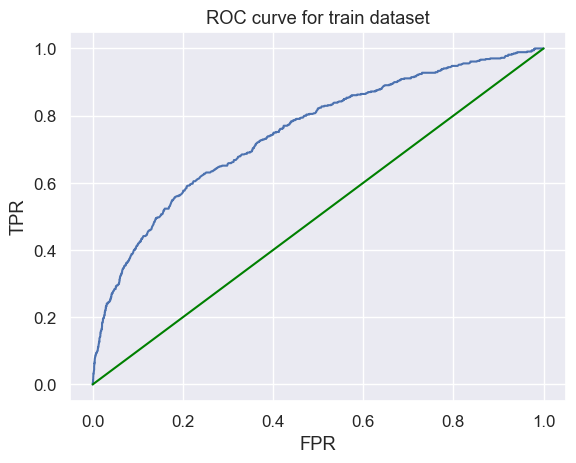

In [385]:
ROCCurve (X_train_stepwise, y_train, "train")

Optimization terminated successfully.
         Current function value: 0.313710
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.313023
         Iterations 8
Area under the ROC curve : 0.757508
Optimal cut-off for accuracy :  [0.13141826687664215]


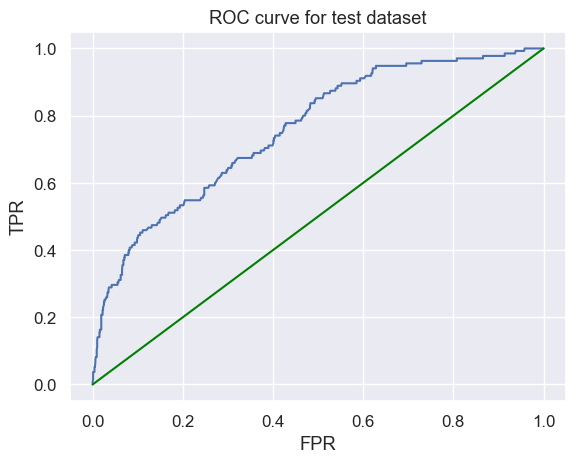

In [386]:
ROCCurve (X_test_stepwise, y_test, "test")

## 2. With tracking data

In [387]:
df_with_tracking= df[["R","goal_angle","assist_type_through_pass","assist_type_long_pass",
                      "shot_bodyPart_head_or_other","direct_free_kick","DDI","shot_isGoal"]]
df_with_tracking.head()

,R,goal_angle,assist_type_through_pass,assist_type_long_pass,shot_bodyPart_head_or_other,direct_free_kick,DDI,shot_isGoal
0,24.624803,16.587813,0,0,0,0,0,0
1,12.127209,14.517517,1,0,0,0,0,0
2,13.676728,10.447233,0,0,0,0,0,0
3,12.396290,5.462242,0,0,1,0,1,0
4,6.845144,33.318625,0,0,1,0,0,0


In [388]:
y = df_with_tracking["shot_isGoal"]
x= df_with_tracking.drop(columns="shot_isGoal")

# cross validation (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
print ("Sample size train dataset: ", X_train.shape)
print ("Sample size test dataset: ", X_test.shape)

Sample size train dataset:  (4531, 7)
Sample size test dataset:  (1133, 7)


In [389]:
result = stepwise_selection(X_train, y_train)
print('resulting features:')
print(result)

Add  R                              with p-value 3.288e-14
Add  assist_type_through_pass       with p-value 3.7e-05
resulting features:
['R', 'assist_type_through_pass']


In [390]:
X_train_stepwise=X_train
for item in X_train.columns:
    if item not in result:
        X_train_stepwise=X_train_stepwise.drop(labels=[item],axis=1) #removes the non relevant variables


X_test_stepwise = X_test
for item in X_test.columns:
    if item not in result:
        X_test_stepwise=X_test_stepwise.drop(labels=[item],axis=1) #removes the non relevant variables


In [391]:
X_train_stepwise = sm.add_constant(X_train_stepwise)

# statsmodels
import statsmodels.api as sm
logit_model=sm.Logit(y_train,X_train_stepwise)
result=logit_model.fit_regularized()
print(result.summary2())

# print Exp(B) and confidence intervals
params = result.params
conf = result.conf_int()
conf['OR'] = params
conf.columns = ['Lower', 'Upper', 'Odds Ratio']
print ("\nexp(B) & confidence intervals: ")
print (np.exp(conf))

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.35045463181219155
            Iterations: 23
            Function evaluations: 27
            Gradient evaluations: 23
                             Results: Logit
Model:                  Logit              Method:             MLE       
Dependent Variable:     shot_isGoal        Pseudo R-squared:   0.024     
Date:                   2025-06-26 00:53   AIC:                3181.8199 
No. Observations:       4531               BIC:                3201.0760 
Df Model:               2                  Log-Likelihood:     -1587.9   
Df Residuals:           4528               LL-Null:            -1626.9   
Converged:              1.0000             LLR p-value:        1.1663e-17
No. Iterations:         23.0000            Scale:              1.0000    
-------------------------------------------------------------------------
                          Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-----

In [392]:
#cutoff=0.5
cutoff = 0.12

train_preds = result.predict(X_train_stepwise)
train_preds_binary = (train_preds > cutoff).astype(int)  # Convert to binary labels (0 o 1)
train_conf_matrix = confusion_matrix(y_train, train_preds_binary)

train_conf_matrix_percentage = train_conf_matrix.astype('float') / train_conf_matrix.sum() * 100
train_conf_matrix_percentage = np.round(train_conf_matrix_percentage, 2)

print("Train dataset confusion matrix")
print(train_conf_matrix_percentage)

Train dataset confusion matrix
[[52.77 35.62]
 [ 3.99  7.61]]


In [393]:
X_test_stepwise = sm.add_constant(X_test_stepwise)

test_preds = result.predict(X_test_stepwise)
test_preds_binary = (test_preds > cutoff).astype(int)  

test_conf_matrix = confusion_matrix(y_test, test_preds_binary)
test_conf_matrix_percentage = test_conf_matrix.astype('float') / test_conf_matrix.sum() * 100
test_conf_matrix_percentage = np.round(test_conf_matrix_percentage, 2)

print(test_conf_matrix_percentage)

[[51.54 35.39]
 [ 4.94  8.12]]


In [394]:
# Accuracy and precision for training set
train_accuracy = accuracy_score(y_train, train_preds_binary)
train_precision = precision_score(y_train, train_preds_binary)
train_recall = recall_score(y_train, train_preds_binary)
train_logloss = log_loss(y_train, train_preds)

print("------------Train------------")
print("Train Accuracy:", train_accuracy)
print("Train Precision:", train_precision)
print("Train Recall:", train_recall)
print("Train Cross-Entropy Loss:", train_logloss)
print("")

# Accuracy and precision for testing set
print("------------Test------------")
test_accuracy = accuracy_score(y_test, test_preds_binary)
test_precision = precision_score(y_test, test_preds_binary)
test_recall = recall_score(y_test, test_preds_binary)
test_logloss = log_loss(y_test, test_preds)

print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Train Recall:", test_recall)
print("Test Cross-Entropy Loss:", test_logloss)


------------Train------------
Train Accuracy: 0.6038402118737586
Train Precision: 0.17611026033690658
Train Recall: 0.655893536121673
Train Cross-Entropy Loss: 0.35045463181219155

------------Test------------
Test Accuracy: 0.5966460723742277
Test Precision: 0.18661257606490872
Train Recall: 0.6216216216216216
Test Cross-Entropy Loss: 0.38505022571442676


Optimization terminated successfully.
         Current function value: 0.350455
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.340595
         Iterations 7
Area under the ROC curve : 0.674193
Optimal cut-off for accuracy :  [0.10527931781526229]


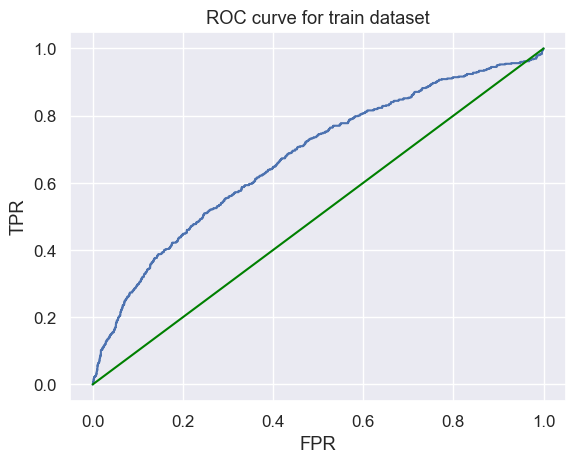

In [395]:
ROCCurve (X_train_stepwise, y_train, "train")

Optimization terminated successfully.
         Current function value: 0.382159
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.377839
         Iterations 7
Area under the ROC curve : 0.623439
Optimal cut-off for accuracy :  [0.13366355030825403]


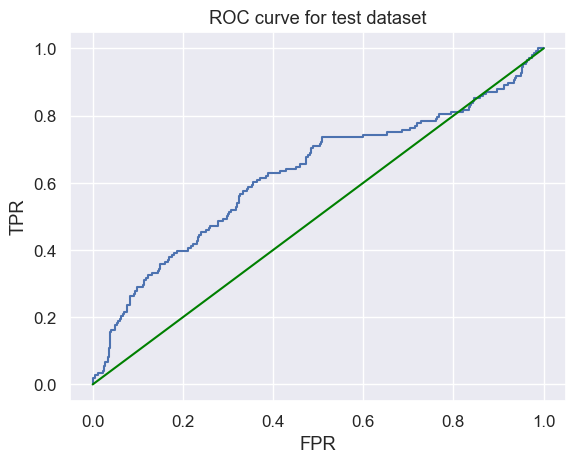

In [396]:
ROCCurve (X_test_stepwise, y_test, "test")